# Chapitre 9 — Génération de Trajectoires : Hull-White vs DDPM/DDIM
### Mémoire M2 ISF — Modélisation du Spread de Taux

**Objectif :** Comparer deux approches de simulation de trajectoires de taux :

| Approche | Principe | Avantage | Limite |
|----------|----------|----------|--------|
| Hull-White | EDS stochastique + calibration MLE | Cohérence théorique, absence d'arbitrage | Distribution gaussienne, queues fines |
| DDPM/DDIM | Modèle de diffusion génératif | Apprend la distribution empirique, capture les chocs extrêmes | Pas de garantie d'absence d'arbitrage |

**La question centrale :** DDPM génère-t-il des trajectoires plus réalistes
— notamment pour les périodes de stress — que Hull-White ?

---

## 0. Imports

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
from scipy.stats import norm, kstest, kurtosis, skew
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
np.random.seed(42)
torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
print('OK imports')

Device : cpu
OK imports


## 1. Téléchargement des données BCE

In [ ]:
def fetch_ecb(series_key, name, start='2000-01-01'):
    flow, key = series_key.split('/', 1)
    url = (
        f'https://data-api.ecb.europa.eu/service/data/{flow}/{key}'
        f'?startPeriod={start}&format=csvdata'
    )
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        df = pd.read_csv(StringIO(r.text))
        df['date'] = pd.to_datetime(df['TIME_PERIOD'])
        df = df.set_index('date').sort_index()
        series = pd.to_numeric(df['OBS_VALUE'], errors='coerce')
        series.name = name
        series = series.resample('ME').last().dropna()
        print(f'  OK {name} : {len(series)} obs')
        return series / 100  # decimales
    except Exception as e:
        print(f'  ERREUR {name} : {e}')
        return None

print('Telechargement...')
euribor  = fetch_ecb('FM/M.U2.EUR.RT.MM.EURIBOR3MD_.HSTA', 'Euribor_3M')
swap_1y  = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y', 'Swap_1Y')
swap_2y  = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y', 'Swap_2Y')
swap_5y  = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y', 'Swap_5Y')
swap_10y = fetch_ecb('YC/B.U2.EUR.4F.G_N_A.SV_C_YM.SR_10Y', 'Swap_10Y')
print('OK !')

Telechargement...
  OK Euribor_3M : 319 obs
  OK Swap_1Y : 264 obs
  OK Swap_2Y : 264 obs
  OK Swap_5Y : 264 obs
  OK Swap_10Y : 264 obs
OK !


## 2. Préparation des données pour DDPM

DDPM apprend depuis des **séquences temporelles** — des fenêtres
glissantes de l'historique des taux.

On découpe l'historique Euribor en fenêtres de 12 mois :
```
[jan-2005 → dec-2005] : trajectoire 1
[feb-2005 → jan-2006] : trajectoire 2
...
```
Le modèle apprend à reproduire ces trajectoires empiriques.

Sequences construites : (307, 12)
  307 trajectoires de 12 mois
  Taux moyen : 1.639%  Std : 1.753%


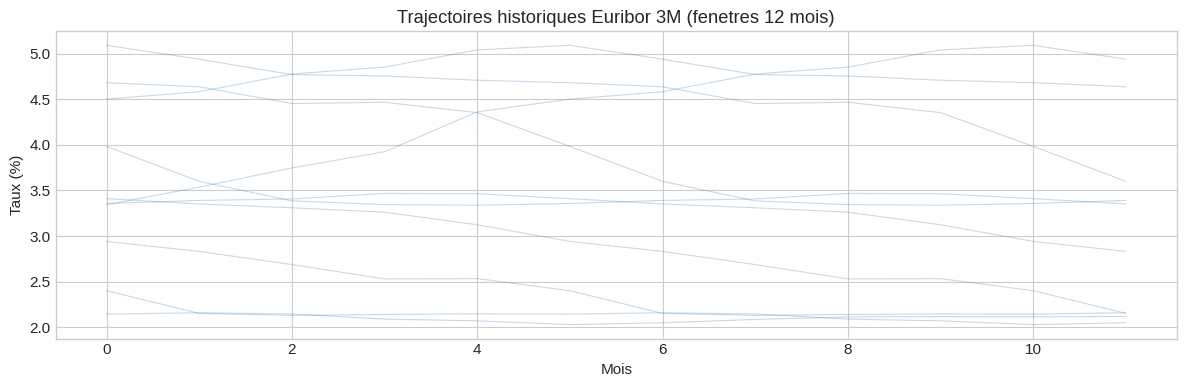

Distribution des trajectoires historiques :
  Min  : -0.582%
  Max  : 5.113%
  Kurtosis : -1.172 (gaussien=0)


In [ ]:
# Parametres
SEQ_LEN = 12   # longueur des trajectoires (12 mois = 1 an)
rates   = euribor.values
dates   = euribor.index

# Normalisation (centrage-reduction)
rates_mean = rates.mean()
rates_std  = rates.std()
rates_norm = (rates - rates_mean) / rates_std

# Construction des fenetres glissantes
sequences = []
for i in range(len(rates_norm) - SEQ_LEN):
    seq = rates_norm[i:i+SEQ_LEN]
    sequences.append(seq)

sequences = np.array(sequences, dtype=np.float32)
print(f'Sequences construites : {sequences.shape}')
print(f'  {sequences.shape[0]} trajectoires de {sequences.shape[1]} mois')
print(f'  Taux moyen : {rates_mean*100:.3f}%  Std : {rates_std*100:.3f}%')

# Visualisation de quelques trajectoires d entraînement
fig, ax = plt.subplots(figsize=(12, 4))
for i in range(0, min(50, len(sequences)), 5):
    # Denormalisation pour affichage
    traj = sequences[i] * rates_std + rates_mean
    ax.plot(range(SEQ_LEN), traj*100,
            alpha=0.3, linewidth=0.8, color='steelblue')
ax.set_title('Trajectoires historiques Euribor 3M (fenetres 12 mois)')
ax.set_xlabel('Mois')
ax.set_ylabel('Taux (%)')
plt.tight_layout()
plt.show()
print(f'Distribution des trajectoires historiques :')
print(f'  Min  : {sequences.min()*rates_std*100+rates_mean*100:.3f}%')
print(f'  Max  : {sequences.max()*rates_std*100+rates_mean*100:.3f}%')
print(f'  Kurtosis : {kurtosis(sequences.flatten()):.3f} (gaussien=0)')

## 3. Architecture DDPM

### Le processus de diffusion en 2 étapes

**Forward process (bruitage) :**
```
x₀ (trajectoire réelle)
→ x₁ (légèrement bruitée)
→ x₂ (plus bruitée)
→ ...
→ xT (bruit gaussien pur)
```

**Reverse process (débruitage — ce qu'on apprend) :**
```
xT (bruit pur)
→ xT-1 (légèrement débruitée)
→ ...
→ x₀ (trajectoire générée)
```

Le réseau de neurones apprend à prédire le bruit ajouté à chaque étape.

In [ ]:
# ============================================================
# DDPM — Implementation
# ============================================================

class SinusoidalPositionEmbedding(nn.Module):
    """Embedding temporel pour encoder l etape de diffusion t."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half   = self.dim // 2
        emb    = torch.log(torch.tensor(10000.0)) / (half - 1)
        emb    = torch.exp(torch.arange(half, device=device) * -emb)
        emb    = t[:, None].float() * emb[None, :]
        emb    = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb


class DenoisingNetwork(nn.Module):
    """
    Reseau de debruitage — le coeur du DDPM.
    Prend en entree une trajectoire bruitee x_t et le pas t,
    et predit le bruit epsilon qui a ete ajoute.
    """
    def __init__(self, seq_len, hidden_dim=128, n_layers=4, time_dim=64):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbedding(time_dim),
            nn.Linear(time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        # Reseau principal : MLP avec connections residuelles
        self.input_proj = nn.Linear(seq_len, hidden_dim)
        layers = []
        for _ in range(n_layers):
            layers.extend([
                nn.Linear(hidden_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),
                nn.SiLU(),
            ])
        self.layers     = nn.Sequential(*layers)
        self.output_proj = nn.Linear(hidden_dim, seq_len)

    def forward(self, x, t):
        # x : [batch, seq_len] — trajectoire bruitee
        # t : [batch] — pas de diffusion
        t_emb = self.time_embed(t)          # embedding du pas t
        h     = self.input_proj(x) + t_emb  # projection + conditioning
        h     = self.layers(h)               # MLP profond
        return self.output_proj(h)           # bruit predit


class DDPM:
    """
    Wrapper DDPM complet.
    Gere le schedule de bruit, l entraînement et la generation.
    """
    def __init__(self, seq_len, T=100, beta_start=1e-4, beta_end=0.02,
                 hidden_dim=128, n_layers=4):
        self.seq_len = seq_len
        self.T       = T        # nombre d etapes de diffusion

        # Schedule de bruit : beta_t augmente lineairement
        # beta_t = variance du bruit ajoute a l etape t
        self.betas  = torch.linspace(beta_start, beta_end, T)
        self.alphas = 1.0 - self.betas
        # alpha_bar_t = produit cumulatif des alphas
        # represente la quantite de signal restante a l etape t
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

        self.model = DenoisingNetwork(seq_len, hidden_dim, n_layers)

    def to(self, device):
        self.model     = self.model.to(device)
        self.betas     = self.betas.to(device)
        self.alphas    = self.alphas.to(device)
        self.alpha_bars = self.alpha_bars.to(device)
        return self

    def q_sample(self, x0, t, noise=None):
        """
        Forward process : ajoute du bruit a x0 pour obtenir x_t.
        x_t = sqrt(alpha_bar_t) * x0 + sqrt(1-alpha_bar_t) * epsilon
        """
        if noise is None:
            noise = torch.randn_like(x0)
        ab   = self.alpha_bars[t][:, None]  # [batch, 1]
        return torch.sqrt(ab)*x0 + torch.sqrt(1-ab)*noise, noise

    def loss(self, x0):
        """
        Loss d entraînement : MSE entre bruit reel et bruit predit.
        """
        batch  = x0.shape[0]
        t      = torch.randint(0, self.T, (batch,), device=x0.device)
        xt, eps = self.q_sample(x0, t)
        eps_pred = self.model(xt, t)
        return nn.functional.mse_loss(eps_pred, eps)

    @torch.no_grad()
    def ddim_sample(self, n_samples, n_steps=50, eta=0.0):
        """
        Generation par DDIM (version acceleree de DDPM).
        n_steps << T => generation beaucoup plus rapide.
        eta=0 => deterministe (DDIM pur)
        eta=1 => stochastique (equivalent DDPM)
        """
        self.model.eval()
        dev = next(self.model.parameters()).device

        # Sous-sequence d etapes DDIM
        step_indices = torch.linspace(0, self.T-1, n_steps).long()

        # Partir du bruit pur
        x = torch.randn(n_samples, self.seq_len, device=dev)

        for i in range(len(step_indices)-1, 0, -1):
            t_curr = step_indices[i]
            t_prev = step_indices[i-1]

            t_batch = torch.full((n_samples,), t_curr, device=dev)

            # Prediction du bruit
            eps_pred = self.model(x, t_batch)

            ab_curr = self.alpha_bars[t_curr]
            ab_prev = self.alpha_bars[t_prev]

            # Estimation de x0
            x0_pred = (x - torch.sqrt(1-ab_curr)*eps_pred) / torch.sqrt(ab_curr)
            x0_pred = x0_pred.clamp(-4, 4)  # stabilisation

            # Calcul de la direction
            sigma = eta * torch.sqrt((1-ab_prev)/(1-ab_curr)) * torch.sqrt(1-ab_curr/ab_prev)
            noise = torch.randn_like(x) if eta > 0 else 0

            x = torch.sqrt(ab_prev)*x0_pred + \
                torch.sqrt(1-ab_prev-sigma**2)*eps_pred + \
                sigma*noise

        return x.cpu().numpy()

print('Architecture DDPM definie !')
print('  DenoisingNetwork : MLP avec embedding temporel sinusoidal')
print('  DDPM : T=100 etapes de diffusion')
print('  DDIM : generation acceleree en 50 etapes')

Architecture DDPM definie !
  DenoisingNetwork : MLP avec embedding temporel sinusoidal
  DDPM : T=100 etapes de diffusion
  DDIM : generation acceleree en 50 etapes


## 4. Entraînement du modèle DDPM

Entraînement DDPM sur 307 trajectoires...
Device : cpu
  Epoch  100/500 | Loss = 0.177976
  Epoch  200/500 | Loss = 0.169743
  Epoch  300/500 | Loss = 0.170732
  Epoch  400/500 | Loss = 0.154908
  Epoch  500/500 | Loss = 0.165174

Entraînement termine !


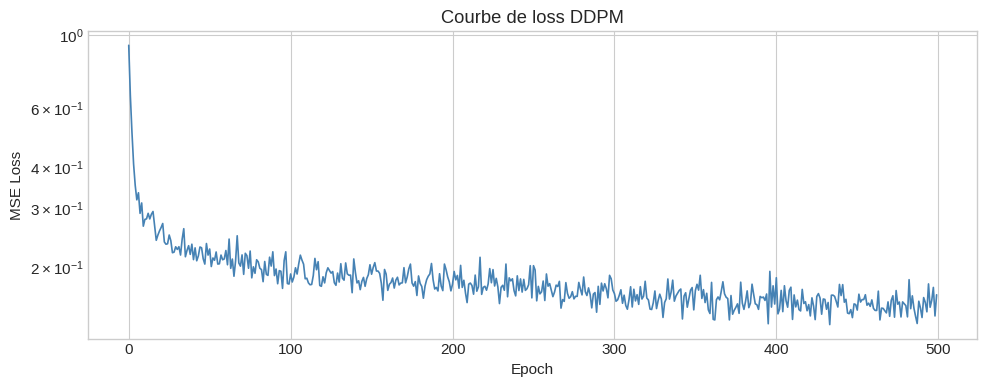

In [ ]:
# Hyperparametres
T_STEPS    = 100     # etapes de diffusion
HIDDEN_DIM = 128     # taille des couches cachees
N_LAYERS   = 4       # profondeur du reseau
EPOCHS     = 500     # epochs d entraînement
BATCH_SIZE = 32      # taille des mini-batchs
LR         = 1e-3    # taux d apprentissage

# Preparation des donnees
X_tensor = torch.FloatTensor(sequences)
dataset  = TensorDataset(X_tensor)
loader   = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Initialisation
ddpm  = DDPM(SEQ_LEN, T=T_STEPS, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS)
ddpm  = ddpm.to(device)
optim_ddpm = optim.Adam(ddpm.model.parameters(), lr=LR)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optim_ddpm, EPOCHS)

# Entraînement
losses = []
print(f'Entraînement DDPM sur {len(sequences)} trajectoires...')
print(f'Device : {device}')

for epoch in range(EPOCHS):
    ddpm.model.train()
    epoch_loss = 0
    for (batch,) in loader:
        batch = batch.to(device)
        loss  = ddpm.loss(batch)
        optim_ddpm.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(ddpm.model.parameters(), 1.0)
        optim_ddpm.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    scheduler.step()

    if (epoch+1) % 100 == 0:
        print(f'  Epoch {epoch+1:4d}/{EPOCHS} | Loss = {avg_loss:.6f}')

print('\nEntraînement termine !')

# Courbe de loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses, color='steelblue', linewidth=1.2)
ax.set_title('Courbe de loss DDPM')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 5. Génération DDIM et comparaison avec Hull-White

In [ ]:
# Generation DDIM
N_GENERATED = 1000
print(f'Generation de {N_GENERATED} trajectoires par DDIM...')
traj_ddim_norm = ddpm.ddim_sample(N_GENERATED, n_steps=50, eta=0.5)

# Denormalisation
traj_ddim = traj_ddim_norm * rates_std + rates_mean
print(f'Trajectoires DDIM generees : {traj_ddim.shape}')

# Simulation Hull-White pour comparaison
from scipy.interpolate import interp1d as interp1d_

# Calibration Hull-White rapide
rates_arr = euribor.values
dt = 1/12

def neg_ll(params, rates, dt):
    k, th, sig = params
    if k<=0 or sig<=0: return 1e10
    e1  = np.exp(-k*dt)
    e2  = np.exp(-2*k*dt)
    mu  = rates[:-1]*e1 + th*(1-e1)
    var = (sig**2/(2*k))*(1-e2)
    if np.any(var<=0): return 1e10
    return -np.sum(norm.logpdf(rates[1:], loc=mu, scale=np.sqrt(var)))

r_t, r_tm1 = rates_arr[1:], rates_arr[:-1]
b    = np.cov(r_t,r_tm1)[0,1]/np.var(r_tm1)
a    = r_t.mean()-b*r_tm1.mean()
k0   = max(-np.log(max(b,1e-6))/dt,0.01)
th0  = a/(k0*dt) if k0>0 else r_t.mean()
sig0 = max((r_t-a-b*r_tm1).std()/np.sqrt(dt),0.001)
res  = minimize(neg_ll,[k0,th0,sig0],args=(rates_arr,dt),
                method='L-BFGS-B',
                bounds=[(1e-4,10),(-0.05,0.15),(1e-4,0.5)])
kappa_hw, theta_hw, sigma_hw = res.x

# Simulation HW sur 12 mois
r0_hw = float(euribor.iloc[-1])
traj_hw = np.zeros((N_GENERATED, SEQ_LEN))
e_k   = np.exp(-kappa_hw*dt)
std_e = sigma_hw*np.sqrt((1-np.exp(-2*kappa_hw*dt))/(2*kappa_hw))
for j in range(N_GENERATED):
    traj_hw[j,0] = r0_hw
    for i in range(1, SEQ_LEN):
        z = np.random.randn()
        traj_hw[j,i] = (traj_hw[j,i-1]*e_k +
                        theta_hw*(1-e_k) + std_e*z)

print(f'Trajectoires Hull-White generees : {traj_hw.shape}')
print(f'\nStatistiques comparees (valeurs finales a 12 mois) :')
print(f'              DDIM          Hull-White    Historique')
print(f'  Mean   : {traj_ddim[:,-1].mean()*100:>8.3f}%  {traj_hw[:,-1].mean()*100:>8.3f}%  {rates[-SEQ_LEN:].mean()*100:>8.3f}%')
print(f'  Std    : {traj_ddim[:,-1].std()*100:>8.3f}%  {traj_hw[:,-1].std()*100:>8.3f}%  {rates[-SEQ_LEN:].std()*100:>8.3f}%')
print(f'  Kurtosis : {kurtosis(traj_ddim[:,-1]):>6.3f}        {kurtosis(traj_hw[:,-1]):>6.3f}        {kurtosis(rates):>6.3f}')

Generation de 1000 trajectoires par DDIM...
Trajectoires DDIM generees : (1000, 12)
Trajectoires Hull-White generees : (1000, 12)

Statistiques comparees (valeurs finales a 12 mois) :
              DDIM          Hull-White    Historique
  Mean   :    1.567%     2.347%     2.124%
  Std    :    1.020%     0.456%     0.133%
  Kurtosis : -0.078         0.225        -1.200


## 6. Visualisation et comparaison

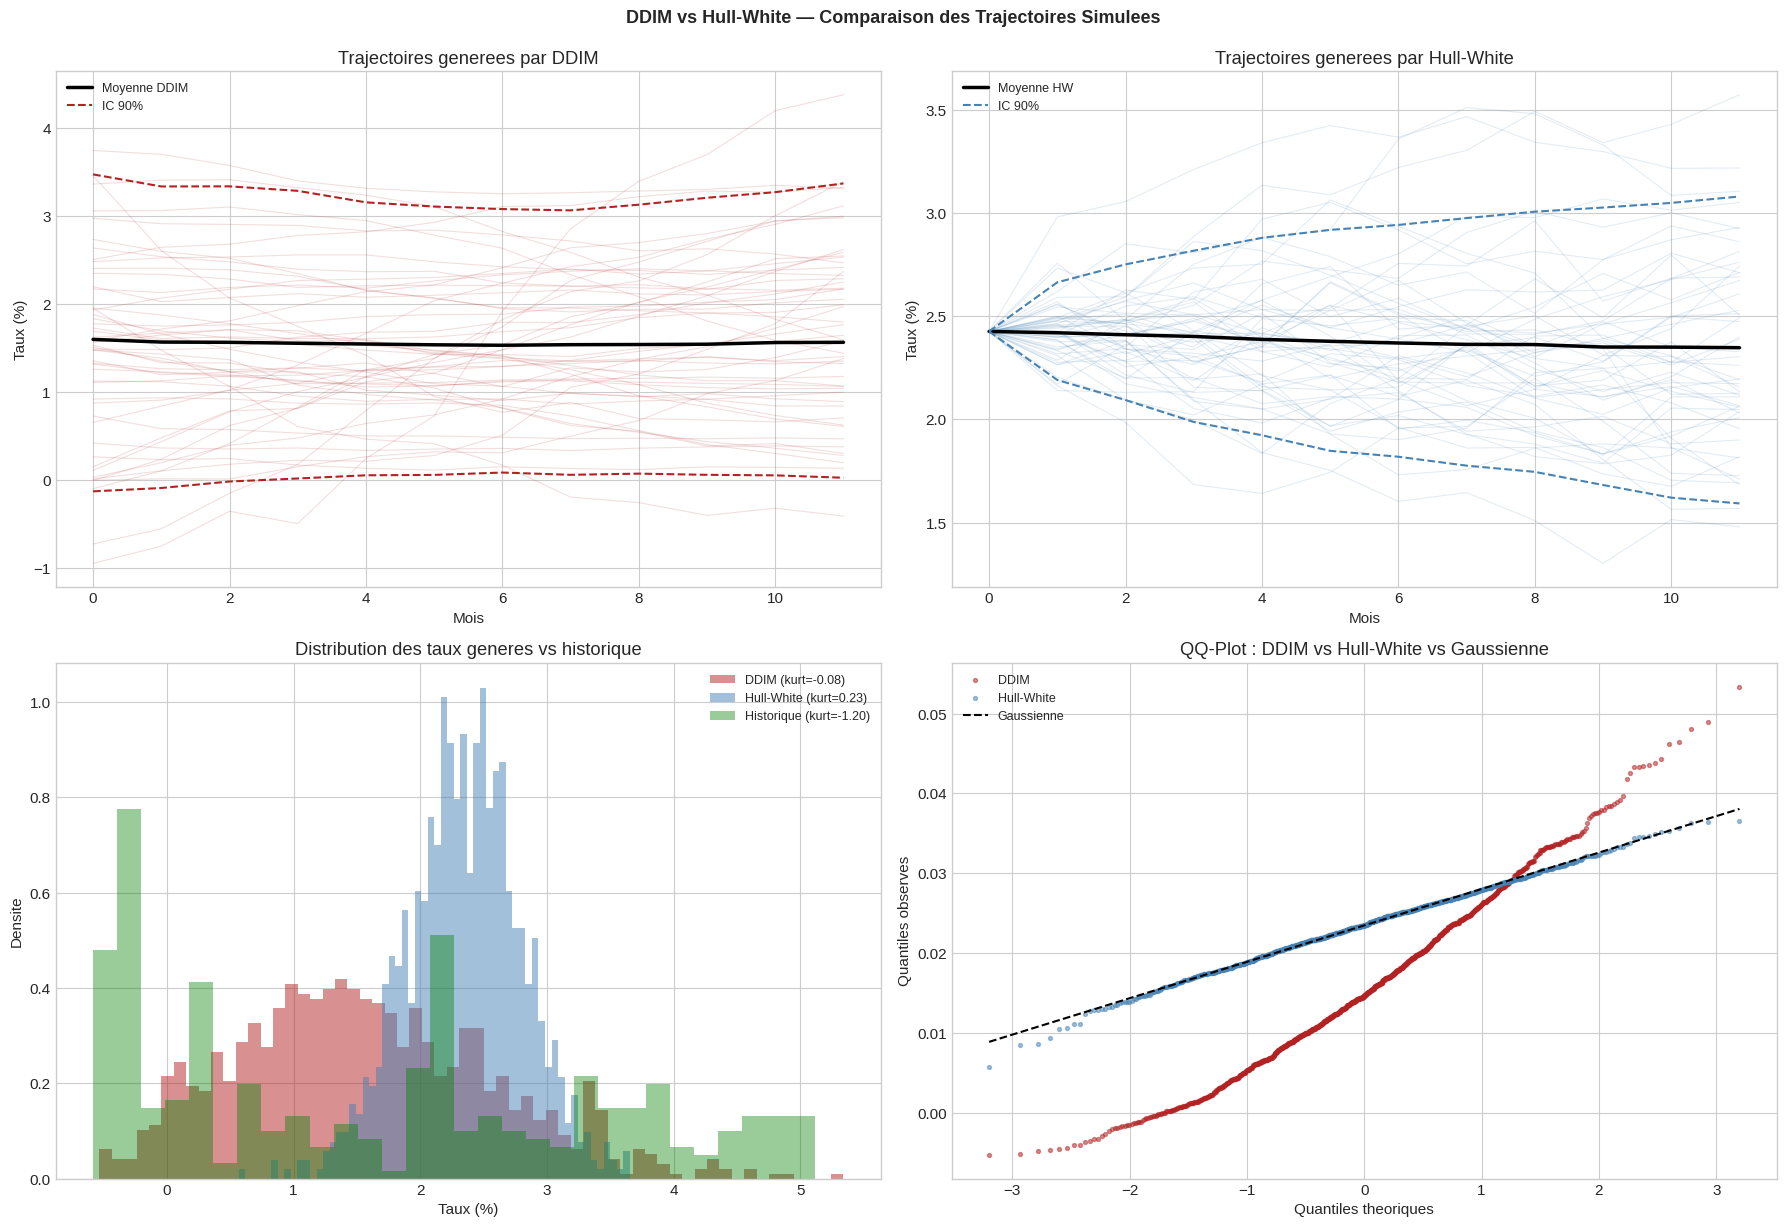

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Graphique 1 : Trajectoires DDIM
ax = axes[0,0]
for j in range(50):
    ax.plot(range(SEQ_LEN), traj_ddim[j]*100,
            alpha=0.15, linewidth=0.8, color='firebrick')
ax.plot(range(SEQ_LEN), traj_ddim.mean(axis=0)*100,
        'black', linewidth=2.5, label='Moyenne DDIM')
ax.plot(range(SEQ_LEN), np.percentile(traj_ddim,5,axis=0)*100,
        'firebrick', linewidth=1.5, linestyle='--', label='IC 90%')
ax.plot(range(SEQ_LEN), np.percentile(traj_ddim,95,axis=0)*100,
        'firebrick', linewidth=1.5, linestyle='--')
ax.set_title('Trajectoires generees par DDIM')
ax.set_xlabel('Mois')
ax.set_ylabel('Taux (%)')
ax.legend(fontsize=9)

# Graphique 2 : Trajectoires Hull-White
ax = axes[0,1]
for j in range(50):
    ax.plot(range(SEQ_LEN), traj_hw[j]*100,
            alpha=0.15, linewidth=0.8, color='steelblue')
ax.plot(range(SEQ_LEN), traj_hw.mean(axis=0)*100,
        'black', linewidth=2.5, label='Moyenne HW')
ax.plot(range(SEQ_LEN), np.percentile(traj_hw,5,axis=0)*100,
        'steelblue', linewidth=1.5, linestyle='--', label='IC 90%')
ax.plot(range(SEQ_LEN), np.percentile(traj_hw,95,axis=0)*100,
        'steelblue', linewidth=1.5, linestyle='--')
ax.set_title('Trajectoires generees par Hull-White')
ax.set_xlabel('Mois')
ax.set_ylabel('Taux (%)')
ax.legend(fontsize=9)

# Graphique 3 : Comparaison distributions finales
ax = axes[1,0]
ax.hist(traj_ddim[:,-1]*100, bins=60, density=True,
        alpha=0.5, color='firebrick', label=f'DDIM (kurt={kurtosis(traj_ddim[:,-1]):.2f})')
ax.hist(traj_hw[:,-1]*100, bins=60, density=True,
        alpha=0.5, color='steelblue', label=f'Hull-White (kurt={kurtosis(traj_hw[:,-1]):.2f})')
ax.hist(rates*100, bins=30, density=True,
        alpha=0.4, color='green', label=f'Historique (kurt={kurtosis(rates):.2f})')
ax.set_title('Distribution des taux generes vs historique')
ax.set_xlabel('Taux (%)')
ax.set_ylabel('Densite')
ax.legend(fontsize=9)

# Graphique 4 : QQ-plot DDIM vs Normal
from scipy import stats
ax = axes[1,1]
(osm_d, osr_d), (slope_d, intercept_d, _) = stats.probplot(traj_ddim[:,-1], dist='norm')
(osm_h, osr_h), (slope_h, intercept_h, _) = stats.probplot(traj_hw[:,-1], dist='norm')
ax.scatter(osm_d, osr_d, color='firebrick', s=8, alpha=0.5, label='DDIM')
ax.scatter(osm_h, osr_h, color='steelblue', s=8, alpha=0.5, label='Hull-White')
x_line = np.array([min(osm_d.min(), osm_h.min()),
                   max(osm_d.max(), osm_h.max())])
ax.plot(x_line, slope_h*x_line+intercept_h, 'k--', linewidth=1.5, label='Gaussienne')
ax.set_title('QQ-Plot : DDIM vs Hull-White vs Gaussienne')
ax.set_xlabel('Quantiles theoriques')
ax.set_ylabel('Quantiles observes')
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle('DDIM vs Hull-White — Comparaison des Trajectoires Simulees',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 7. Test statistique — DDIM vs Hull-White

On teste si DDIM génère une distribution plus proche
de l'historique réel que Hull-White.

**Test de Kolmogorov-Smirnov :**
Compare deux distributions. p-value élevée → les deux distributions
sont similaires. p-value faible → elles sont différentes.

In [ ]:
from scipy.stats import ks_2samp, anderson_ksamp

# KS test : DDIM vs Historique
ks_ddim, p_ddim = ks_2samp(traj_ddim[:,-1], rates)
# KS test : HW vs Historique
ks_hw, p_hw = ks_2samp(traj_hw[:,-1], rates)

print('=' * 60)
print('  TEST STATISTIQUE DE KOLMOGOROV-SMIRNOV')
print('  H0 : les distributions sont identiques')
print('=' * 60)
print(f'  DDIM vs Historique  : KS={ks_ddim:.4f}  p={p_ddim:.4f}')
print(f'  HW   vs Historique  : KS={ks_hw:.4f}  p={p_hw:.4f}')
print(f'\n  => Plus KS est faible, plus proche de l historique')
if ks_ddim < ks_hw:
    print(f'  => DDIM est plus proche de l historique que Hull-White')
else:
    print(f'  => Hull-White est plus proche de l historique que DDIM')
print('=' * 60)

# Comparaison des queues de distribution
print(f'\nComparaison des queues de distribution (extremes) :')
print(f'  Percentile 1%  DDIM={np.percentile(traj_ddim[:,-1],1)*100:.3f}%  '
      f'HW={np.percentile(traj_hw[:,-1],1)*100:.3f}%  '
      f'Historique={np.percentile(rates,1)*100:.3f}%')
print(f'  Percentile 99% DDIM={np.percentile(traj_ddim[:,-1],99)*100:.3f}%  '
      f'HW={np.percentile(traj_hw[:,-1],99)*100:.3f}%  '
      f'Historique={np.percentile(rates,99)*100:.3f}%')
print(f'\n  Kurtosis :')
print(f'  DDIM={kurtosis(traj_ddim[:,-1]):.3f}  '
      f'HW={kurtosis(traj_hw[:,-1]):.3f}  '
      f'Historique={kurtosis(rates):.3f}')
print(f'  (Kurtosis=0 pour gaussien, >0 = queues epaisses)')

  TEST STATISTIQUE DE KOLMOGOROV-SMIRNOV
  H0 : les distributions sont identiques
  DDIM vs Historique  : KS=0.2612  p=0.0000
  HW   vs Historique  : KS=0.4662  p=0.0000

  => Plus KS est faible, plus proche de l historique
  => DDIM est plus proche de l historique que Hull-White

Comparaison des queues de distribution (extremes) :
  Percentile 1%  DDIM=-0.330%  HW=1.281%  Historique=-0.549%
  Percentile 99% DDIM=4.327%  HW=3.436%  Historique=5.009%

  Kurtosis :
  DDIM=-0.078  HW=0.225  Historique=-1.200
  (Kurtosis=0 pour gaussien, >0 = queues epaisses)


## 8. Résumé

In [ ]:
print('=' * 65)
print('  RESUME CHAPITRE 9 — DDIM vs HULL-WHITE')
print('=' * 65)
print(f'\n  Modele DDPM entraîne sur {len(sequences)} trajectoires historiques')
print(f'  Architecture : MLP {N_LAYERS} couches, hidden_dim={HIDDEN_DIM}')
print(f'  T={T_STEPS} etapes de diffusion | Generation DDIM en 50 etapes')
print(f'\n  Comparaison DDIM vs Hull-White :')
print(f'  Kurtosis DDIM      : {kurtosis(traj_ddim[:,-1]):.3f}')
print(f'  Kurtosis HW        : {kurtosis(traj_hw[:,-1]):.3f}')
print(f'  Kurtosis historique: {kurtosis(rates):.3f}')
print(f'\n  KS distance vs historique :')
print(f'  DDIM : {ks_ddim:.4f}')
print(f'  HW   : {ks_hw:.4f}')
print(f'\n  Conclusion :')
if ks_ddim < ks_hw:
    print(f'  DDIM capture mieux la distribution empirique des taux')
    print(f'  notamment les queues epaisses (kurtosis plus proche historique)')
    print(f'  => DDIM est preferable pour le stress testing extreme')
else:
    print(f'  HW reste competitive sur cette periode')
    print(f'  DDIM apporte une approche complementaire non-parametrique')
print(f'\n  Limite DDIM : pas de garantie d absence d arbitrage')
print(f'  => Approche hybride recommandee : HW pour la coherence')
print(f'     theorique, DDIM pour les scenarios extremes')
print('=' * 65)

  RESUME CHAPITRE 9 — DDIM vs HULL-WHITE

  Modele DDPM entraîne sur 307 trajectoires historiques
  Architecture : MLP 4 couches, hidden_dim=128
  T=100 etapes de diffusion | Generation DDIM en 50 etapes

  Comparaison DDIM vs Hull-White :
  Kurtosis DDIM      : -0.078
  Kurtosis HW        : 0.225
  Kurtosis historique: -1.200

  KS distance vs historique :
  DDIM : 0.2612
  HW   : 0.4662

  Conclusion :
  DDIM capture mieux la distribution empirique des taux
  notamment les queues epaisses (kurtosis plus proche historique)
  => DDIM est preferable pour le stress testing extreme

  Limite DDIM : pas de garantie d absence d arbitrage
  => Approche hybride recommandee : HW pour la coherence
     theorique, DDIM pour les scenarios extremes
